In [27]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [28]:
class AgentState(TypedDict):
    number1:int
    number2: int
    operation:str
    result:int

In [29]:
def adder(state:AgentState)-> AgentState:
    """This node adds two numbers"""
    state['result']=state['number1']+state['number2']
    return state
    
def subtract(state:AgentState)-> AgentState:
    """This node subtracts two numbers"""
    state['result']=state['number1']-state['number2']
    return state

def decide_next_snode(state:AgentState)->str:
    """This node will select the next node of the graph"""
    if state['operation']=="+":
        return "add_op"
    elif state['operation']=="-":
        return "subtract_op"

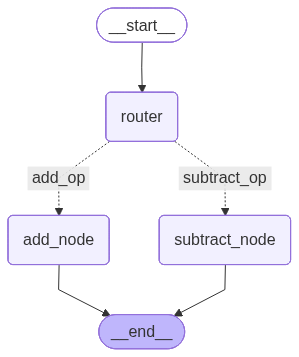

In [30]:
graph=StateGraph(AgentState)
graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtract)
graph.add_node('router', lambda state:state)# passthrough function

graph.add_edge(START, 'router')
graph.add_conditional_edges(
    "router",
    decide_next_snode,
    {
        'add_op':'add_node',
        'subtract_op':'subtract_node'
    }
)
graph.add_edge('add_node', END)
graph.add_edge('subtract_node', END)

bot=graph.compile()
bot

In [32]:
input_state={
    'number1':10,
    'number2':4,
    'operation':"+"
}
final_response=bot.invoke(input_state)
final_response

{'number1': 10, 'number2': 4, 'operation': '+', 'result': 14}